# Converting to DGL graphs

Again, start from a `PyVista` dataset:

In [12]:
from cooldata.pyvista_flow_field_dataset import PyvistaFlowFieldDataset

ds_pv = PyvistaFlowFieldDataset.load_from_huggingface(
    num_samples=2, data_dir="datasets/pyvista"
)
ds_pv[0]

Loaded 2 samples from '/nfs/homedirs/peo/flow_field_dataset/docs/usage/datasets/pyvista'.
Loaded 2 samples from 'datasets/pyvista'.


2025-06-08 21:24:03.278 ( 148.697s) [    7479E03EC740]      vtkCGNSReader.cxx:4267  WARN| vtkCGNSReader (0x5857e36b72c0): Skipping BC_t node: BC_t type 'BCInflow' not supported yet.
2025-06-08 21:24:03.279 ( 148.697s) [    7479E03EC740]      vtkCGNSReader.cxx:4267  WARN| vtkCGNSReader (0x5857e36b72c0): Skipping BC_t node: BC_t type 'BCSymmetryPlane' not supported yet.
2025-06-08 21:24:03.279 ( 148.697s) [    7479E03EC740]      vtkCGNSReader.cxx:4267  WARN| vtkCGNSReader (0x5857e36b72c0): Skipping BC_t node: BC_t type 'BCTunnelOutflow' not supported yet.


Now, let us convert the `PyVista` dataset to a `DGL` graph. This requires some computation, and is implemented in a parallelized way.

In [2]:
from cooldata.dgl_flow_field_dataset import DGLSurfaceFlowFieldDataset

ds_dgl_surface = DGLSurfaceFlowFieldDataset(
    "datasets/dgl_surface", ds_pv
)

Let us now explore what the graphs look like:

In [3]:
ds_dgl_surface[0]

Graph(num_nodes=35350, num_edges=282774,
      ndata_schemes={'HeatTransferCoefficient': Scheme(shape=(), dtype=torch.float32), 'BodyID': Scheme(shape=(), dtype=torch.int32), 'SurfaceType': Scheme(shape=(), dtype=torch.int32), 'CellArea': Scheme(shape=(), dtype=torch.float32), 'Normal': Scheme(shape=(3,), dtype=torch.float32), 'ShearStress': Scheme(shape=(3,), dtype=torch.float32), 'Position': Scheme(shape=(3,), dtype=torch.float32), 'Temperature': Scheme(shape=(), dtype=torch.float32), 'Pressure': Scheme(shape=(), dtype=torch.float32)}
      edata_schemes={'dx': Scheme(shape=(3,), dtype=torch.float32)})

Again, we can visualize the graph:

In [4]:
import pyvista as pv
pv.set_jupyter_backend('static')

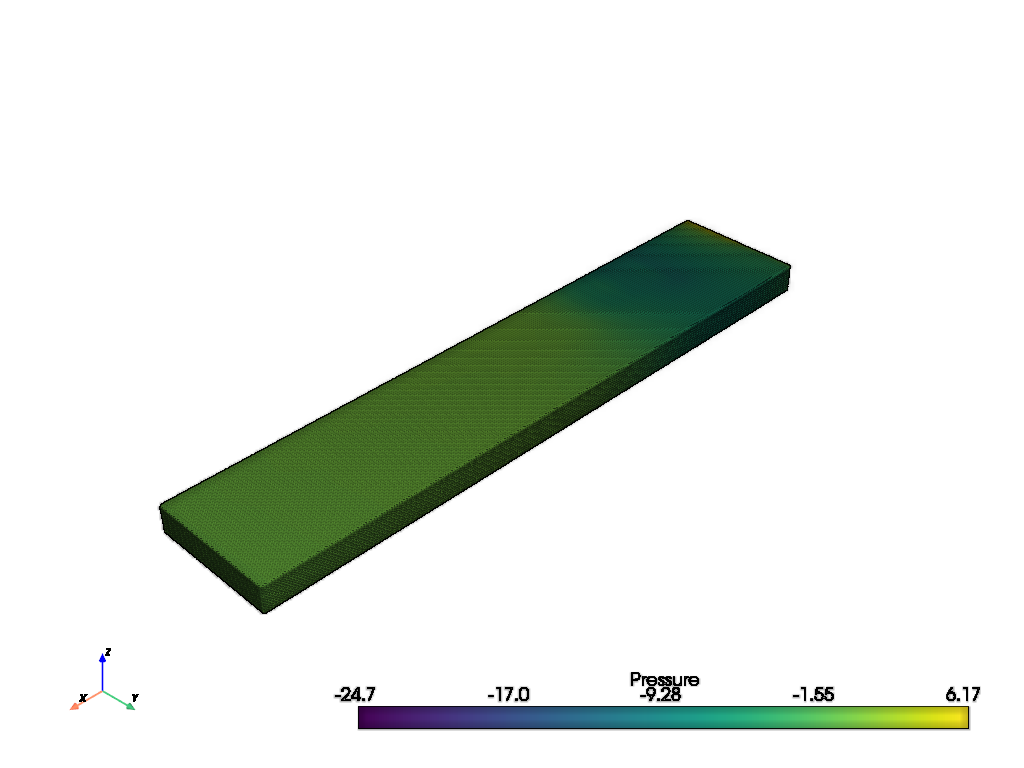

In [10]:
ds_dgl_surface.plot_surface(ds_dgl_surface[0],"Pressure")

You can find a full training script [here](https://github.com/peteole/flow_field_dataset/blob/main/examples/meshgraphnet/train.ipynb).

It is possible to use the volumetric data as a graph as well:

In [8]:
from cooldata.dgl_flow_field_dataset import DGLVolumeFlowFieldDataset


ds_dgl_volume = DGLVolumeFlowFieldDataset("datasets/dgl_volume", ds_pv)

The graphs will have a significantly larger number of nodes and edges:

In [9]:
ds_dgl_volume[0]

Graph(num_nodes=192498, num_edges=4690894,
      ndata_schemes={'Volume': Scheme(shape=(), dtype=torch.float32), 'TurbulentKineticEnergy': Scheme(shape=(), dtype=torch.float32), 'TurbulentDissipationRate': Scheme(shape=(), dtype=torch.float32), 'Velocity': Scheme(shape=(3,), dtype=torch.float32), 'Position': Scheme(shape=(3,), dtype=torch.float32), 'Temperature': Scheme(shape=(), dtype=torch.float32), 'Pressure': Scheme(shape=(), dtype=torch.float32)}
      edata_schemes={'dx': Scheme(shape=(3,), dtype=torch.float32)})